In [45]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

uploaded = files.upload()


for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')
  df = pd.read_csv(fn)



Saving reservations_train.csv to reservations_train.csv
User uploaded file "reservations_train.csv"


# 1) Exploratory data analysis et preparation

In [3]:
# Afficher les informations du DataFrame
display(df.shape)
display(df.info())
display(df.head())


(8000, 34)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   reservation_id             8000 non-null   object 
 1   date_reservation           8000 non-null   object 
 2   date_arrivee               8000 non-null   object 
 3   region_hotel               8000 non-null   object 
 4   ville                      8000 non-null   object 
 5   type_destination           8000 non-null   object 
 6   hotel_id                   8000 non-null   object 
 7   categorie_hotel            8000 non-null   int64  
 8   segment_client             8000 non-null   object 
 9   marche_origine             7809 non-null   object 
 10  canal_reservation          8000 non-null   object 
 11  moyen_transport            8000 non-null   object 
 12  delai_reservation_jours    8000 non-null   int64  
 13  nuits                      8000 non-null   int64

None

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,...,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,...,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,...,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,...,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,...,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,...,0,0,2.0,1,0,0,0,0,NaN,0


In [4]:
display(df.describe())
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(df[col].value_counts())
    print("-----------------------------")


,categorie_hotel,delai_reservation_jours,nuits,adultes,enfants,chambres,prix_moyen_nuit_eur,remise_pct,montant_total_eur,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,reservation_annulee
count,8000.000000,8000.000000,8000.000000,8000.000000,7645.000000,8000.000000,7807.000000,8000.000000,8000.000000,8000.000000,8000.000000,7843.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,3.832500,41.379625,4.203375,2.086125,0.529235,1.266875,201.473548,4.999625,1009.584740,2.416875,0.341250,0.917124,0.327875,0.323000,0.113250,0.436125,0.283625,0.258375
std,0.705873,49.232410,2.524492,0.914364,0.943367,0.664423,62.550478,3.649629,879.585635,3.785879,0.602573,0.887739,0.617795,1.787686,0.316918,0.495934,0.450785,0.437769
min,3.000000,1.000000,1.000000,1.000000,0.000000,1.000000,75.250000,0.000000,85.440000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,16.000000,2.000000,2.000000,0.000000,1.000000,158.945000,2.000000,475.615000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,29.000000,4.000000,2.000000,0.000000,1.000000,191.580000,5.000000,786.950000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.000000,49.000000,6.000000,2.000000,1.000000,1.000000,233.210000,7.000000,1252.420000,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,5.000000,584.000000,30.000000,6.000000,3.000000,4.000000,848.420000,18.000000,13509.190000,12.000000,3.000000,4.000000,4.000000,15.000000,1.000000,1.000000,1.000000,1.000000


reservation_id
R003197    1
R001185    1
R000692    1
R009078    1
R008927    1
          ..
R004683    1
R003635    1
R002130    1
R001808    1
R000808    1
Name: count, Length: 8000, dtype: int64
-----------------------------
date_reservation
2023-12-15    20
2023-08-26    19
2023-07-25    19
2024-11-29    19
2025-01-14    18
              ..
2023-08-16     3
2023-10-08     3
2024-07-15     3
2025-04-15     2
2023-07-03     1
Name: count, Length: 875, dtype: int64
-----------------------------
date_arrivee
2023-09-10    19
2025-03-29    18
2024-10-14    18
2024-08-10    18
2024-09-29    17
              ..
2025-08-14     1
2025-09-22     1
2026-05-29     1
2026-02-01     1
2025-07-10     1
Name: count, Length: 979, dtype: int64
-----------------------------
region_hotel
Lazio                  1349
Lombardia              1100
Veneto                 1013
Toscana                 978
Campania                782
Trentino-Alto_Adige     661
Liguria                 646
Sicilia              

In [5]:
df.isnull().mean() * 100


,0
reservation_id,0.0000
date_reservation,0.0000
date_arrivee,0.0000
region_hotel,0.0000
ville,0.0000
type_destination,0.0000
hotel_id,0.0000
categorie_hotel,0.0000
segment_client,0.0000
marche_origine,2.3875


In [6]:
# 1. Créer une colonne binaire explicite
df['is_direct_booking'] = df['agent_id'].isnull().astype(int)

# 2. Remplacer le null par une catégorie explicite (utile pour groupby, modèles, etc.)
df['agent_id'] = df['agent_id'].fillna('DIRECT')

df['prix_moyen_nuit_eur'].fillna(df['prix_moyen_nuit_eur'].median(), inplace=True)
df['demandes_speciales'] = df['demandes_speciales'].fillna('Aucune')
df['marche_origine'] = df['marche_origine'].fillna('Unknown')

display(df['enfants'].value_counts(dropna=False))
df['enfants'].fillna(df['enfants'].median(), inplace=True)

/tmp/ipykernel_729/1637619995.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['prix_moyen_nuit_eur'].fillna(df['prix_moyen_nuit_eur'].median(), inplace=True)


,count
enfants,
0.0,5441
1.0,969
2.0,628
3.0,607
NaN,355


/tmp/ipykernel_729/1637619995.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['enfants'].fillna(df['enfants'].median(), inplace=True)


In [7]:
df.duplicated().sum()

np.int64(0)

In [42]:
df['date_reservation'] = pd.to_datetime(df['date_reservation'])
df = df.sort_values('date_reservation')
cutoff_date = df['date_reservation'].quantile(0.8)
train = df[df['date_reservation'] < cutoff_date]
test = df[df['date_reservation'] >= cutoff_date]

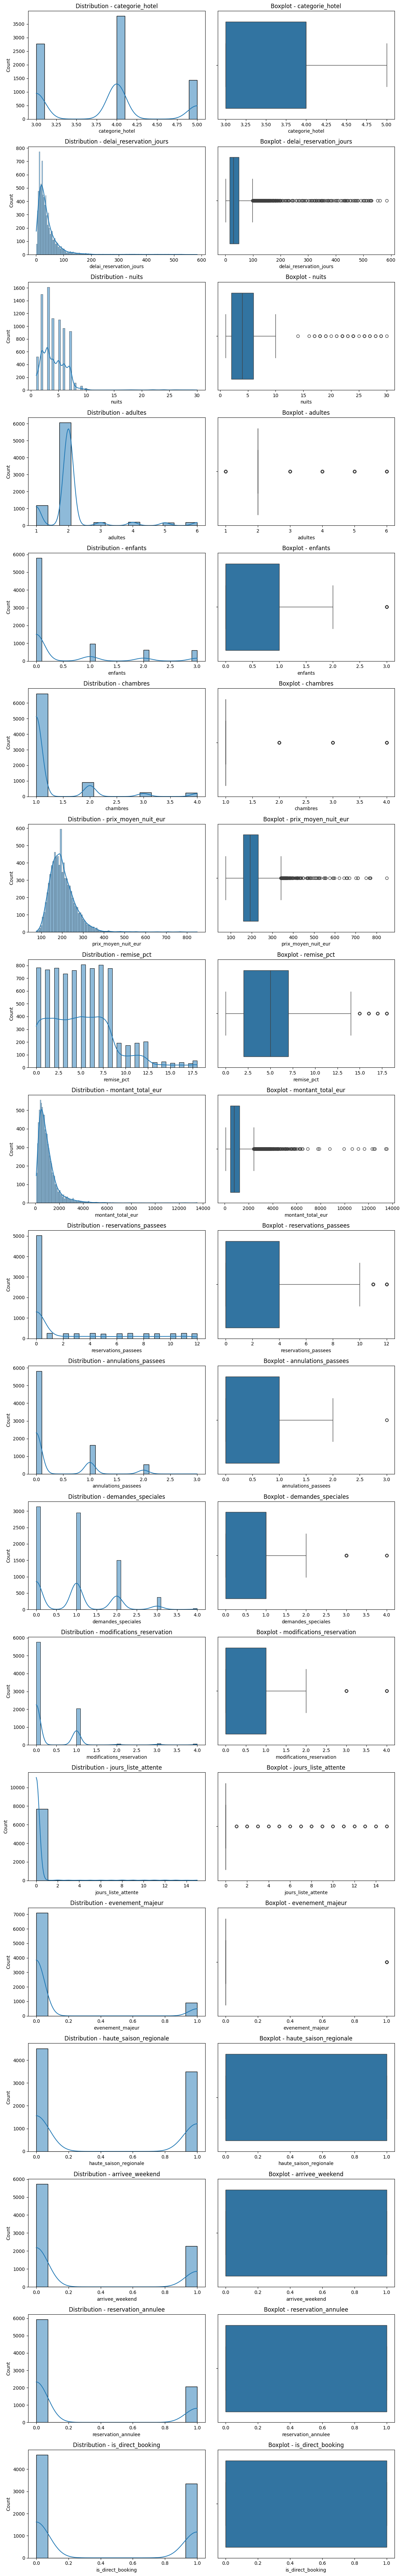

In [46]:
#distribution analysis
#variable numeriques
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4*len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogramme + KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribution - {col}')

    # Boxplot pour repérer les outliers
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

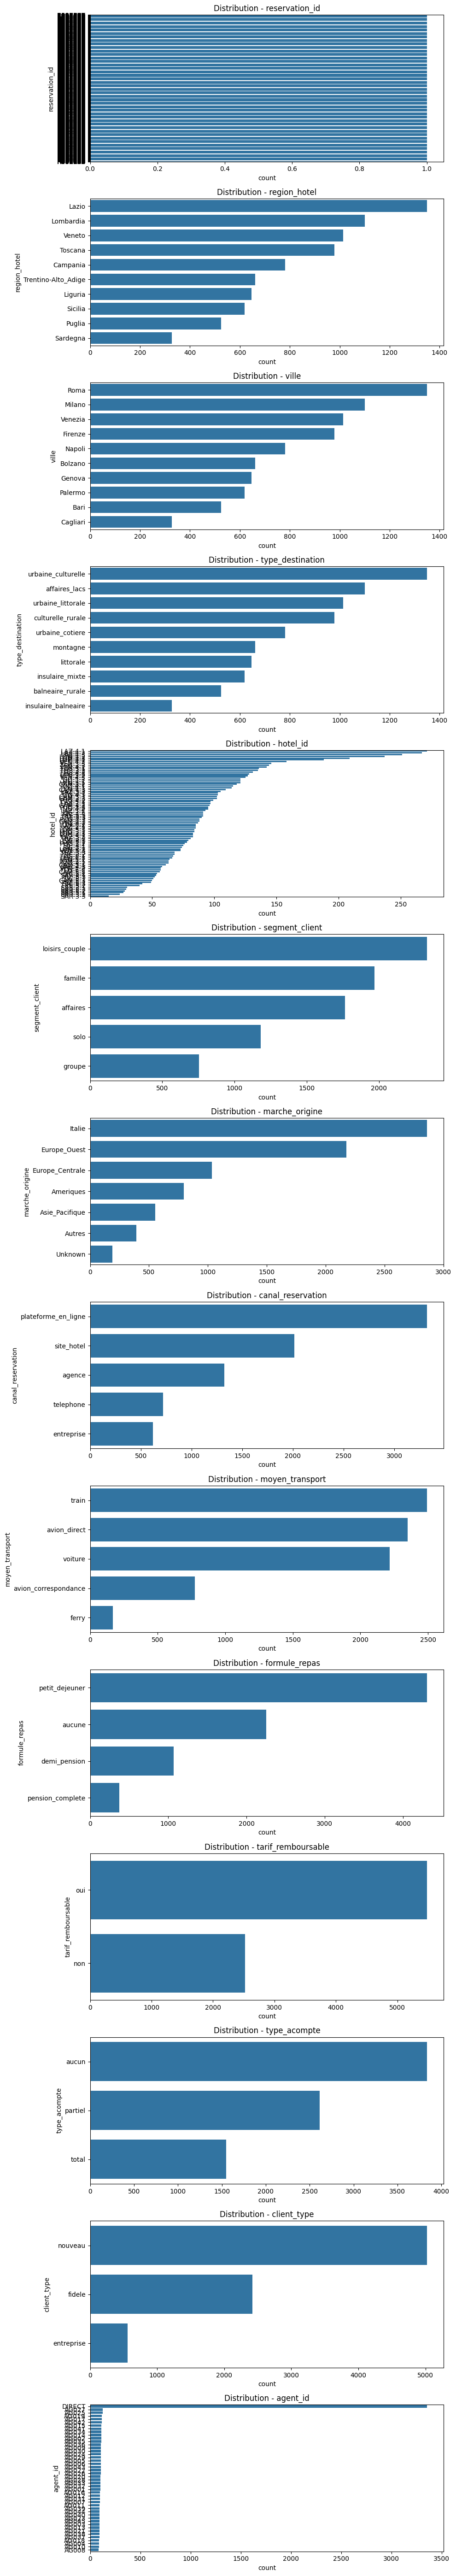

In [47]:
#variable categorielle
cat_cols = df.select_dtypes(include=['object', 'category']).columns

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4*len(cat_cols)))

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i] if len(cat_cols) > 1 else axes)
    (axes[i] if len(cat_cols) > 1 else axes).set_title(f'Distribution - {col}')

plt.tight_layout()
plt.show()

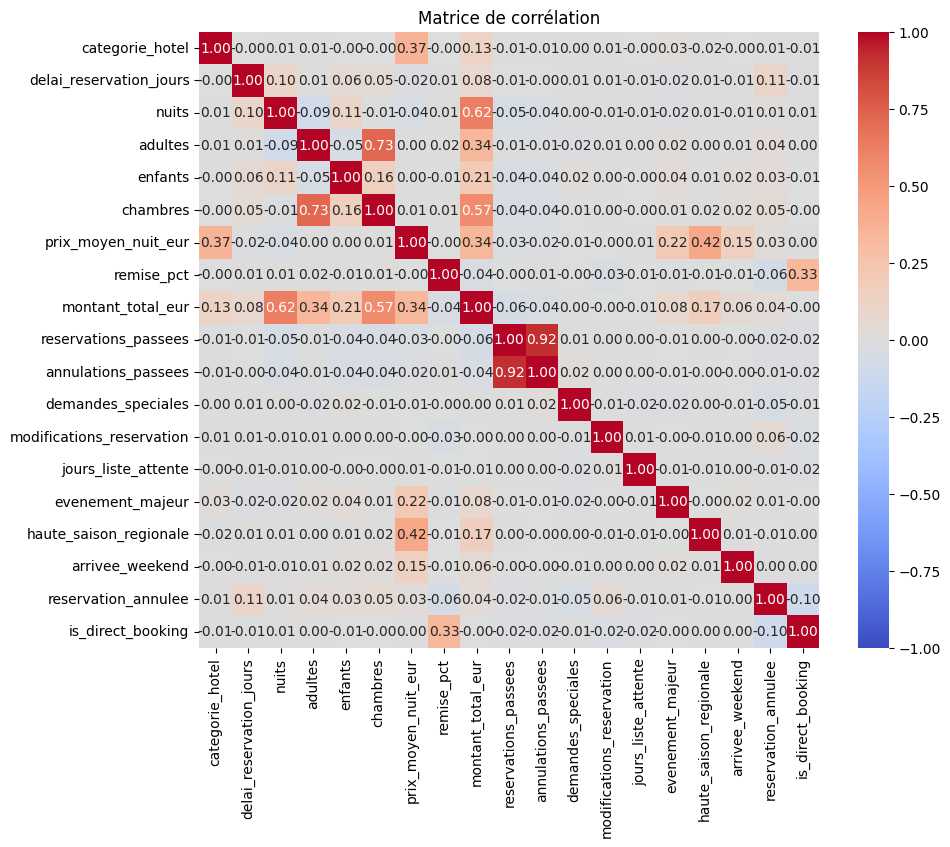

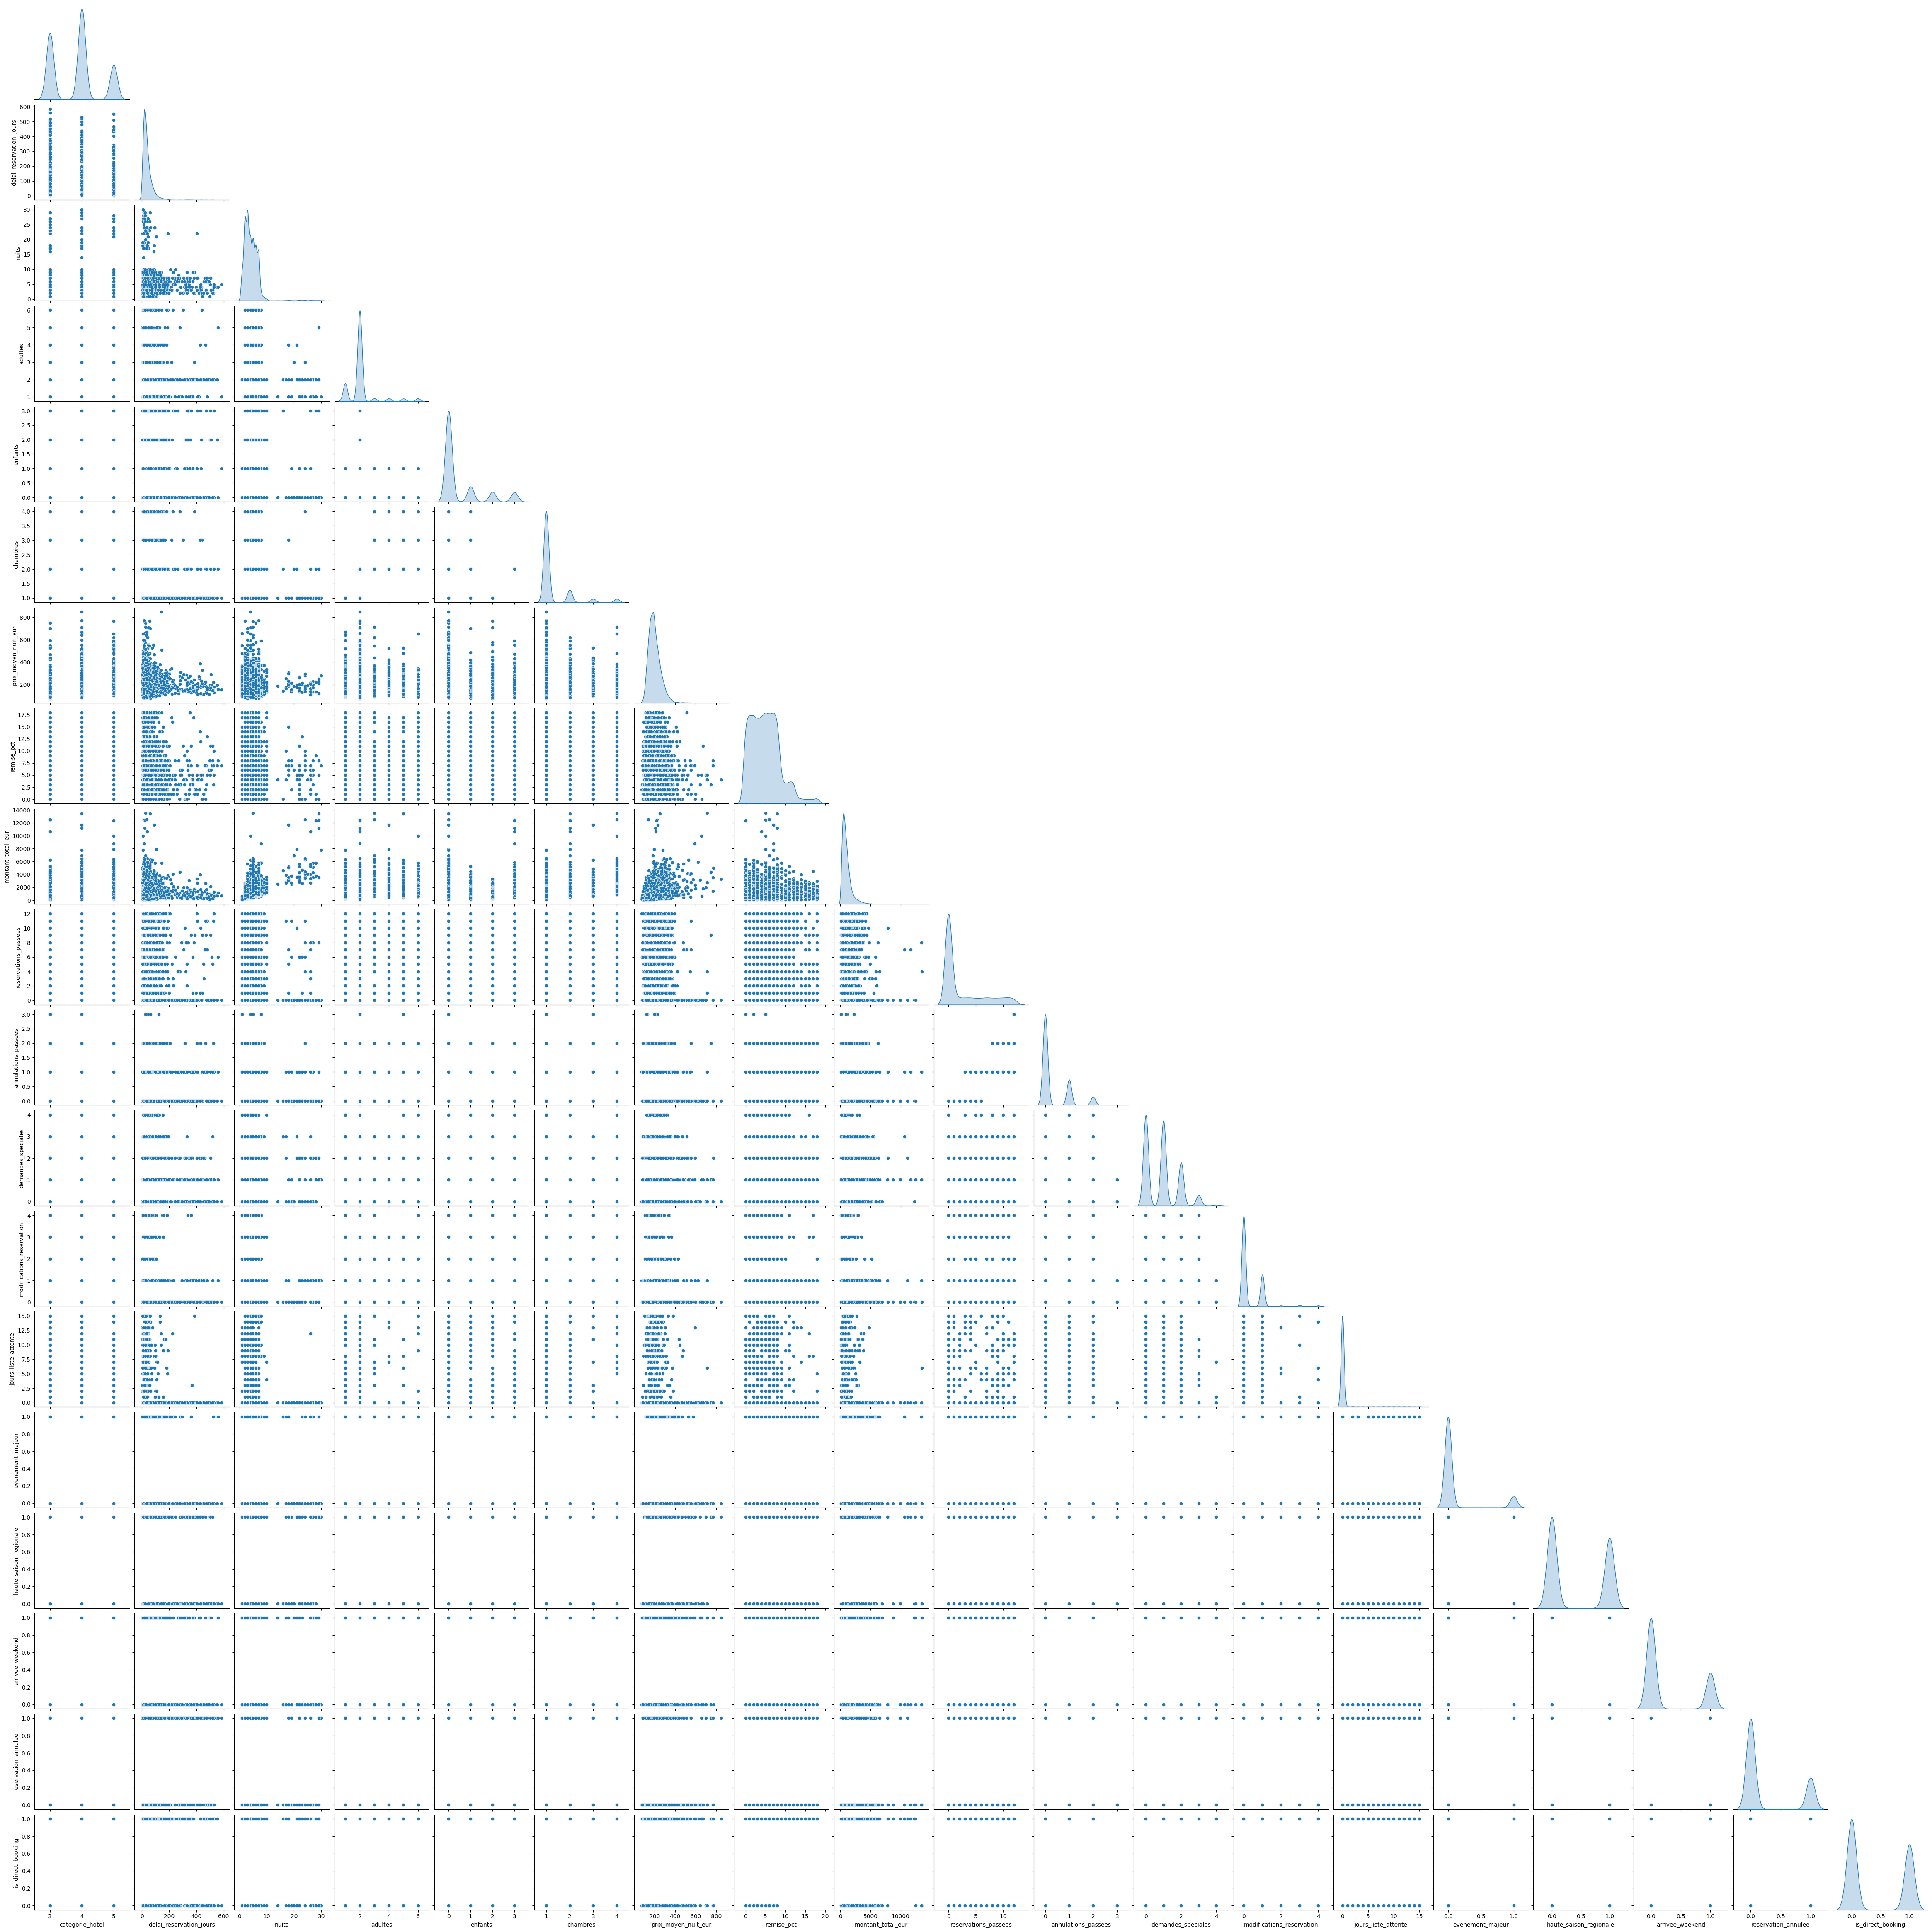

In [48]:
#analyse des relations
#1 numérique

corr = df[num_cols].corr(method='pearson')  # ou 'spearman' si relations non-linéaires/outliers

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
plt.show()
sns.pairplot(df[num_cols], diag_kind='kde', corner=True)
plt.show()

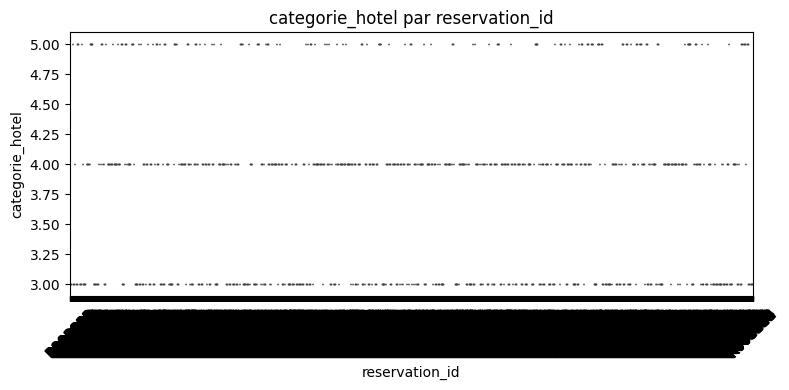

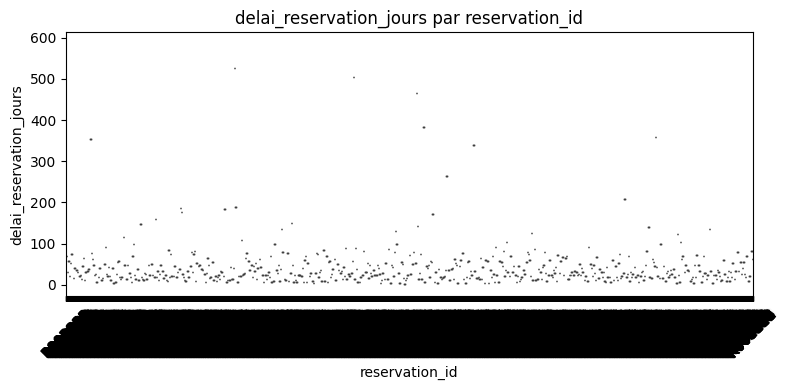

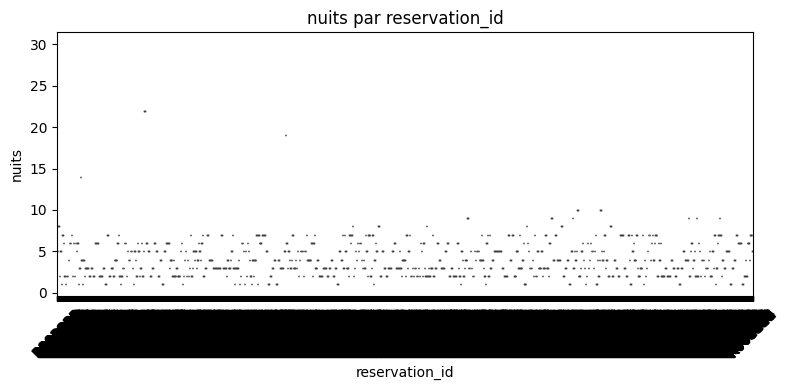

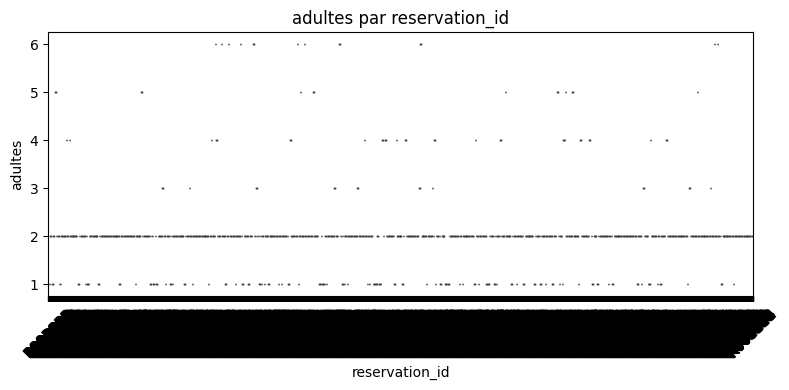

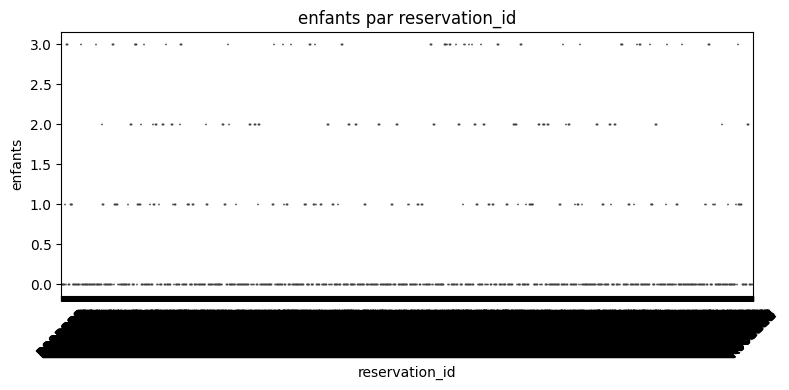

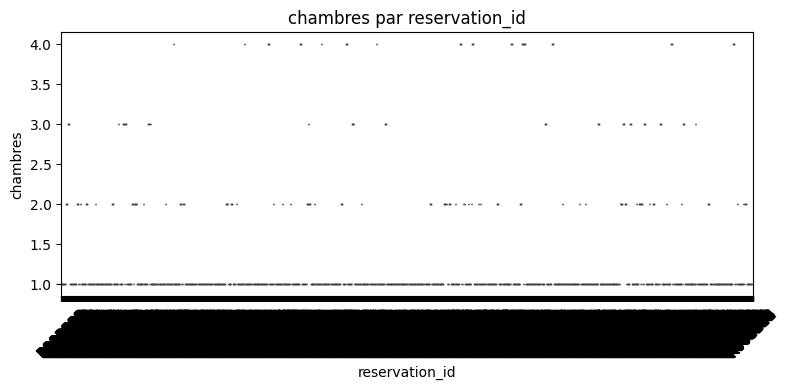

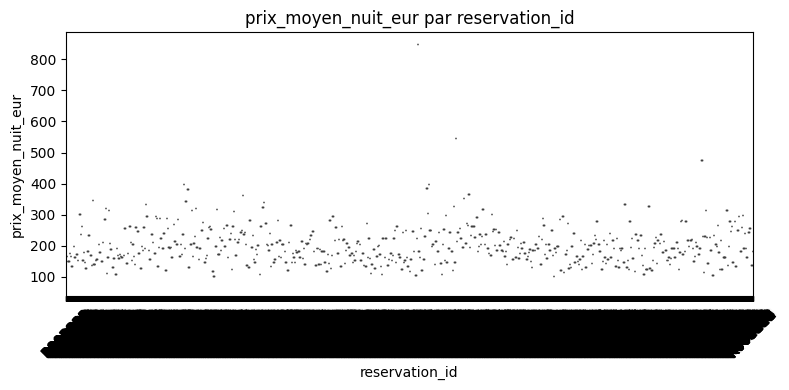

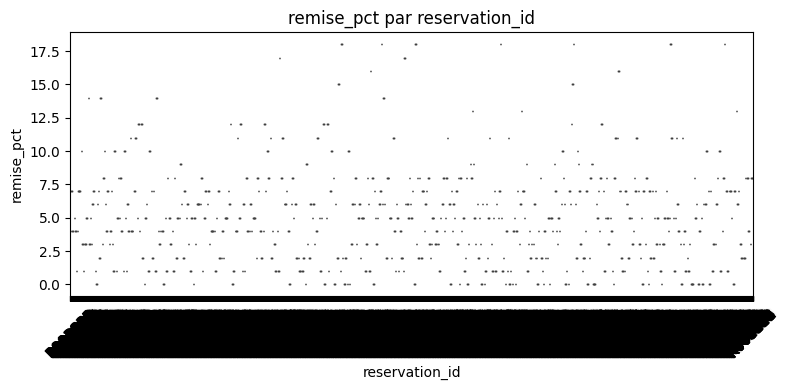

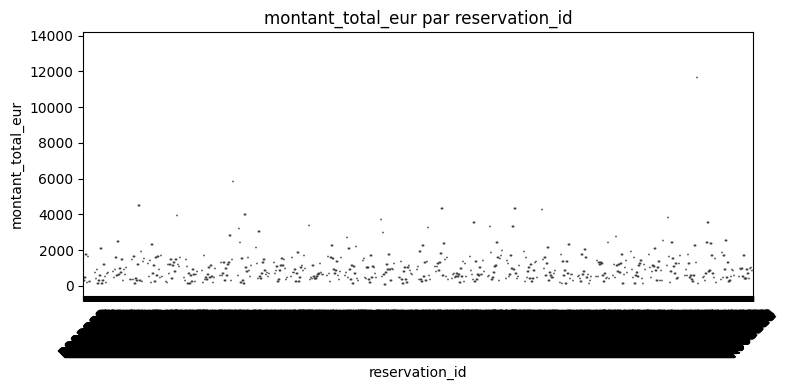

In [ ]:
#2 numerique - categorielle

for cat in cat_cols:
    for num in num_cols:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x=cat, y=num)
        plt.xticks(rotation=45)
        plt.title(f'{num} par {cat}')
        plt.tight_layout()
        plt.show()

In [ ]:
sns.violinplot(data=df, x='is_direct_booking', y='prix_moyen_nuit_eur')

In [ ]:
# Corrélation de chaque variable numérique avec la target
target = 'prix_moyen_nuit_eur'
correlations = df[num_cols].corr()[target].sort_values(ascending=False)
print(correlations)

In [ ]:
df.set_index('date_reservation')['prix_moyen_nuit_eur'].resample('M').mean().plot(figsize=(12,4))
plt.title('Évolution du prix moyen par mois')
plt.show()

# 2) Baseline — Régression logistique

On complète d'abord deux points d'EDA indispensables avant de construire le pipeline : la distribution de la cible, et la conversion des dates (nécessaire pour le split temporel).


In [8]:
# Imports (au cas où le kernel a été redémarré / cette section relancée seule)
import pandas as pd
import numpy as np


In [9]:
# Distribution de la cible (à vérifier avant de choisir métriques / seuil)
print(df['reservation_annulee'].value_counts(normalize=True) * 100)


reservation_annulee
0    74.1625
1    25.8375
Name: proportion, dtype: float64


In [10]:
# Conversion des dates (obligatoire pour un split respectant l'ordre temporel)
df['date_reservation'] = pd.to_datetime(df['date_reservation'])
df['date_arrivee'] = pd.to_datetime(df['date_arrivee'])

# On trie par date d'arrivée : le jeu de test officiel contient les réservations les plus récentes
df = df.sort_values('date_arrivee').reset_index(drop=True)


In [11]:
# Correction : demandes_speciales est numérique (compte de demandes), pas catégoriel.
# Le fillna('Aucune') du nettoyage précédent a mélangé str et float dans la colonne,
# ce qui fait planter OneHotEncoder plus loin. On remet 'Aucune' -> 0 et on repasse en float.
if df['demandes_speciales'].dtype == object:
    df['demandes_speciales'] = df['demandes_speciales'].replace('Aucune', 0).astype(float)

print(df['demandes_speciales'].dtype)
print(df['demandes_speciales'].value_counts().sort_index())


float64
demandes_speciales
0.0    3141
1.0    2954
2.0    1505
3.0     371
4.0      29
Name: count, dtype: int64


/tmp/ipykernel_729/3960720027.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['demandes_speciales'] = df['demandes_speciales'].replace('Aucune', 0).astype(float)


## 2.1) Split temporel train / validation

On garde les 20% de réservations les plus récentes comme validation interne, pour simuler la situation du vrai `reservations_test.csv` (données futures par rapport au train).


In [12]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
val_df = df.iloc[split_index:].copy()

print(f"Train      : {train_df.shape[0]} lignes, du {train_df['date_arrivee'].min().date()} au {train_df['date_arrivee'].max().date()}")
print(f"Validation : {val_df.shape[0]} lignes, du {val_df['date_arrivee'].min().date()} au {val_df['date_arrivee'].max().date()}")


Train      : 6400 lignes, du 2023-01-04 au 2025-01-07
Validation : 1600 lignes, du 2025-01-07 au 2026-06-02


## 2.2) Vérification des colonnes redondantes

`ville` et `type_destination` semblent liées 1-à-1 à `region_hotel` (chaque région italienne correspond à une seule ville et un seul type de destination dans ce dataset synthétique). On vérifie ça avant de les garder toutes dans le modèle, pour éviter la redondance inutile.


In [13]:
# Si chaque région a exactement 1 ville et 1 type_destination associés, la colonne est redondante
print("Villes distinctes par région :")
print(pd.crosstab(df['region_hotel'], df['ville']).astype(bool).sum(axis=1))
print("\nTypes de destination distincts par région :")
print(pd.crosstab(df['region_hotel'], df['type_destination']).astype(bool).sum(axis=1))


Villes distinctes par région :
region_hotel
Campania               1
Lazio                  1
Liguria                1
Lombardia              1
Puglia                 1
Sardegna               1
Sicilia                1
Toscana                1
Trentino-Alto_Adige    1
Veneto                 1
dtype: int64

Types de destination distincts par région :
region_hotel
Campania               1
Lazio                  1
Liguria                1
Lombardia              1
Puglia                 1
Sardegna               1
Sicilia                1
Toscana                1
Trentino-Alto_Adige    1
Veneto                 1
dtype: int64


## 2.3) Construction du pipeline de préprocessing

**Important : le pipeline apprend l'imputation, le scaling et l'encodage uniquement sur `X_train` (via `.fit()`), puis les réapplique tels quels sur `X_val` (via `.transform()`) — c'est ce que fait automatiquement `Pipeline.fit()` / `.predict()` de scikit-learn, ça évite toute fuite de données.**

Adapte `redundant_cols` selon le résultat de la cellule précédente (si les crosstabs ne donnent pas 1 partout, retire `ville` ou `type_destination` de cette liste).


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Colonnes à exclure du modèle : identifiants, cible, dates brutes (pas exploitables telles quelles)
id_cols = ['reservation_id', 'hotel_id', 'date_reservation', 'date_arrivee']
target_col = 'reservation_annulee'

# À ajuster selon la cellule 2.2 : colonnes jugées redondantes avec region_hotel
redundant_cols = ['ville', 'type_destination']

drop_cols = id_cols + redundant_cols + [target_col]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]
X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target_col]

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print('Variables numériques   :', numeric_features)
print('Variables catégorielles:', categorical_features)

# Garde-fou : force les colonnes catégorielles en texte pur, au cas où une autre colonne
# aurait un mélange de types (nombre + texte) suite à un nettoyage manuel en amont.
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_val[categorical_features] = X_val[categorical_features].astype(str)


Variables numériques   : ['categorie_hotel', 'delai_reservation_jours', 'nuits', 'adultes', 'enfants', 'chambres', 'prix_moyen_nuit_eur', 'remise_pct', 'montant_total_eur', 'reservations_passees', 'annulations_passees', 'demandes_speciales', 'modifications_reservation', 'jours_liste_attente', 'evenement_majeur', 'haute_saison_regionale', 'arrivee_weekend', 'is_direct_booking']
Variables catégorielles: ['region_hotel', 'segment_client', 'marche_origine', 'canal_reservation', 'moyen_transport', 'formule_repas', 'tarif_remboursable', 'type_acompte', 'client_type', 'agent_id']


In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


## 2.4) Entraînement et évaluation de la baseline


In [16]:
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_val)
y_proba = baseline_model.predict_proba(X_val)[:, 1]


In [17]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

print('F1-score (classe annulée) :', round(f1_score(y_val, y_pred), 4))
print()
print('Rapport de classification :')
print(classification_report(y_val, y_pred, target_names=['maintenue', 'annulée']))
print('Matrice de confusion :')
print(confusion_matrix(y_val, y_pred))


F1-score (classe annulée) : 0.2138

Rapport de classification :
              precision    recall  f1-score   support

   maintenue       0.74      0.96      0.84      1157
     annulée       0.54      0.13      0.21       443

    accuracy                           0.73      1600
   macro avg       0.64      0.54      0.52      1600
weighted avg       0.69      0.73      0.66      1600

Matrice de confusion :
[[1107   50]
 [ 384   59]]


**À faire ensuite :**
- Une fois l'EDA de ton coéquipier finalisée, réintègre ses décisions (traitement des outliers, colonnes à exclure) dans les cellules 2.2/2.3 ci-dessus — le pipeline est structuré pour que ça reste rapide à ajuster.
- Interprète le F1-score obtenu ici : c'est ton point de référence pour l'étape 3 (comparer au moins deux autres familles de modèles) et l'étape 4 (feature engineering).
- Regarde la matrice de confusion : combien de faux négatifs (annulations manquées) vs faux positifs (fausses alertes) — ça alimente directement la discussion sur le seuil de décision à l'étape 5.


# 3) Validation et modélisation

On réutilise le même `preprocessor` (imputation + scaling + encodage) que pour la baseline — seul le classifieur final change. On compare deux familles différentes de la régression logistique :
- **Random Forest** : combine plusieurs arbres de décision entraînés sur des sous-échantillons, vote majoritaire.
- **Gradient Boosting** : construit les arbres un par un, chacun corrige les erreurs du précédent.

**Important : on garde le même split temporel (`train_df`/`val_df`) que pour la baseline — jamais de mélange aléatoire, sinon on casse la logique de validation dans le temps.**


In [18]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

candidate_models = {
    'Régression logistique (baseline)': baseline_model,
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ])
}


## 3.1) Comparaison des modèles sur la validation temporelle


In [19]:
results = []

for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)
    results.append({'modele': name, 'f1_score': round(f1, 4)})
    print(f"{name:40s} F1 = {f1:.4f}")

results_df = pd.DataFrame(results).sort_values('f1_score', ascending=False)
results_df


Régression logistique (baseline)         F1 = 0.2138
Random Forest                            F1 = 0.1155
Gradient Boosting                        F1 = 0.1839


,modele,f1_score
0,Régression logistique (baseline),0.2138
2,Gradient Boosting,0.1839
1,Random Forest,0.1155


## 3.2) Réglage des hyperparamètres (respectant l'ordre temporel)

`GridSearchCV` mélange les données par défaut — on lui passe donc un objet `TimeSeriesSplit` à la place d'un `cv` classique, pour que chaque découpage garde les données les plus anciennes en entraînement et les plus récentes en validation.

Exemple ici sur le Random Forest (souvent le meilleur compromis performance/temps de calcul). Adapte `param_grid` si tu veux aussi tuner le Gradient Boosting.


In [20]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# df est déjà trié par date_arrivee : TimeSeriesSplit respecte cet ordre automatiquement
tscv = TimeSeriesSplit(n_splits=5)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [8, 16, None],
    'classifier__min_samples_leaf': [1, 5]
}

# On tune sur tout df trié (X = df sans cible/drop_cols) pour profiter des 5 découpages temporels
X_full = df.drop(columns=drop_cols)
y_full = df[target_col]
X_full[categorical_features] = X_full[categorical_features].astype(str)

grid_search = GridSearchCV(rf_pipeline, param_grid, scoring='f1', cv=tscv, n_jobs=-1, verbose=1)
grid_search.fit(X_full, y_full)

print('Meilleurs paramètres :', grid_search.best_params_)
print('Meilleur F1 (moyenne sur les 5 découpages) :', round(grid_search.best_score_, 4))


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Meilleurs paramètres : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
Meilleur F1 (moyenne sur les 5 découpages) : 0.0923


## 3.3) Réévaluation du meilleur modèle sur la validation

On reprend le meilleur modèle trouvé par le `GridSearchCV`, mais on l'évalue proprement sur notre split fixe `train_df`/`val_df` (celui utilisé pour la baseline), pour comparer sur une base identique.


In [21]:
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best_rf = best_rf.predict(X_val)

print('F1-score Random Forest (réglé) :', round(f1_score(y_val, y_pred_best_rf), 4))
print(classification_report(y_val, y_pred_best_rf, target_names=['maintenue', 'annulée']))


F1-score Random Forest (réglé) : 0.1302
              precision    recall  f1-score   support

   maintenue       0.73      0.97      0.84      1157
     annulée       0.52      0.07      0.13       443

    accuracy                           0.72      1600
   macro avg       0.62      0.52      0.48      1600
weighted avg       0.67      0.72      0.64      1600



## 3.4) Ajustement du seuil de décision

Par défaut, le seuil est 0.5. On teste plusieurs seuils sur les probabilités prédites pour voir leur effet sur le F1-score et sur le compromis faux positifs / faux négatifs — c'est ce que le sujet demande d'expliciter (mission critique : ne pas pénaliser inutilement les clients qui maintiennent leur séjour).


In [22]:
import numpy as np

y_proba_best = best_rf.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    f1_t = f1_score(y_val, y_pred_t)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()
    threshold_results.append({
        'seuil': round(t, 2), 'f1_score': round(f1_t, 4),
        'faux_positifs': fp, 'faux_negatifs': fn
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

best_threshold_row = threshold_df.loc[threshold_df['f1_score'].idxmax()]
print('Meilleur seuil pour le F1-score :', best_threshold_row['seuil'], '-> F1 =', best_threshold_row['f1_score'])


,seuil,f1_score,faux_positifs,faux_negatifs
0,0.10,0.4516,1028,14
1,0.15,0.4693,852,46
2,0.20,0.4842,684,83
3,0.25,0.4854,518,135
4,0.30,0.4457,387,205
5,0.35,0.4023,260,266
6,0.40,0.3429,161,318
7,0.45,0.2327,81,374
8,0.50,0.1302,31,410
9,0.55,0.0473,11,432


Meilleur seuil pour le F1-score : 0.25 -> F1 = 0.4854


**À faire ensuite :**
- Compare le F1 obtenu ici à celui de la baseline (section 2) — le gain doit être net pour justifier la complexité ajoutée, sinon garder le modèle le plus simple reste défendable.
- Le seuil optimal trouvé en 3.4 n'est pas forcément 0.5 : documente ce choix dans le README (compromis faux positifs / faux négatifs).
- Une fois satisfait du modèle et du seuil, on passe à l'étape 4 (feature engineering) pour essayer d'améliorer encore le F1, en réutilisant exactement la même structure de pipeline.


## 3.5) Correction : gestion du déséquilibre des classes

Au seuil 0.5, les modèles ratent la majorité des annulations (déséquilibre ~72%/28%). On rééquilibre via `sample_weight` : chaque exemple de la classe minoritaire (`annulée`) pèse plus lourd pendant l'entraînement, proportionnellement à sa rareté. C'est un raisonnement générique qui fonctionne pour les 3 modèles (contrairement à `class_weight`, non disponible pour `GradientBoostingClassifier`).


In [23]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

balanced_models = {
    'Régression logistique (balanced)': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest (balanced)': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting (balanced)': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ])
}

for name, model in balanced_models.items():
    model.fit(X_train, y_train, classifier__sample_weight=sample_weights)
    y_pred = model.predict(X_val)
    print(f"{name:38s} F1 @ seuil 0.5 = {f1_score(y_val, y_pred):.4f}")


Régression logistique (balanced)       F1 @ seuil 0.5 = 0.4874
Random Forest (balanced)               F1 @ seuil 0.5 = 0.1000
Gradient Boosting (balanced)           F1 @ seuil 0.5 = 0.4850


## 3.6) Comparaison finale : chaque modèle à son meilleur seuil

Comparer les modèles au seuil 0.5 reste trompeur pour un problème déséquilibré. On calcule, pour chaque modèle, le seuil qui maximise son propre F1 sur la validation, puis on compare les modèles sur cette base — c'est ce résultat qui doit guider ton choix final de modèle et de seuil.


In [24]:
def best_threshold_f1(model, X_val, y_val, thresholds=np.arange(0.05, 0.95, 0.02)):
    proba = model.predict_proba(X_val)[:, 1]
    scores = [(t, f1_score(y_val, (proba >= t).astype(int))) for t in thresholds]
    best_t, best_f1 = max(scores, key=lambda x: x[1])
    return best_t, best_f1

final_comparison = []
for name, model in balanced_models.items():
    best_t, best_f1 = best_threshold_f1(model, X_val, y_val)
    final_comparison.append({'modele': name, 'meilleur_seuil': round(best_t, 2), 'f1_score': round(best_f1, 4)})

final_df = pd.DataFrame(final_comparison).sort_values('f1_score', ascending=False)
final_df


,modele,meilleur_seuil,f1_score
2,Gradient Boosting (balanced),0.45,0.5000
0,Régression logistique (balanced),0.39,0.4882
1,Random Forest (balanced),0.23,0.4844


**À faire ensuite :**
- Regarde le tableau `final_df` : c'est la comparaison la plus juste entre les 3 modèles. Le modèle gagnant + son seuil optimal deviennent ta référence pour l'étape 4.
- Dans ton README, explique ce choix : pourquoi le rééquilibrage était nécessaire, et pourquoi le seuil retenu n'est pas 0.5 (lien direct avec le compromis faux positifs/négatifs demandé).
- Optionnel si le temps le permet : relancer le `GridSearchCV` de la section 3.2 avec `sample_weight` (via `classifier__sample_weight` dans `fit_params`) pour un réglage plus fin, mais ce n'est pas indispensable si `final_df` te donne déjà un modèle satisfaisant.


# 4) Feature engineering

On crée des variables à partir des dates, du séjour, du prix et de l'historique client. On repart de `df` (déjà trié par `date_arrivee`), on garde le **même `split_index`** que l'étape 2 pour ne pas casser la logique temporelle, puis on compare le F1 avant/après pour démontrer un gain réel (et pas juste supposé).

## 4.1) Création des nouvelles variables

In [25]:
# On repart de df (trié par date_arrivee) pour créer les variables sur l'ensemble des données,
# puis on refera le split train/val avec le même split_index qu'à l'étape 2.

df_fe = df.copy()

# --- Variables temporelles ---
# Délai entre réservation et arrivée : un délai très court ou très long peut être lié au risque d'annulation
df_fe['delai_reservation_jours'] = (df_fe['date_arrivee'] - df_fe['date_reservation']).dt.days

df_fe['mois_arrivee'] = df_fe['date_arrivee'].dt.month
df_fe['jour_semaine_arrivee'] = df_fe['date_arrivee'].dt.dayofweek  # 0 = lundi
df_fe['arrivee_weekend'] = df_fe['jour_semaine_arrivee'].isin([5, 6]).astype(int)

# --- Variables liées au séjour ---
df_fe['personnes_totales'] = df_fe['adultes'] + df_fe['enfants']
df_fe['nuits_par_chambre'] = df_fe['nuits'] / df_fe['chambres'].replace(0, 1)
df_fe['personnes_par_chambre'] = df_fe['personnes_totales'] / df_fe['chambres'].replace(0, 1)

# --- Variables liées au prix ---
df_fe['prix_total_par_personne'] = df_fe['montant_total_eur'] / df_fe['personnes_totales'].replace(0, 1)
df_fe['remise_appliquee'] = (df_fe['remise_pct'] > 0).astype(int)

# --- Variables liées à l'historique client ---
# reservations_passees / annulations_passees décrivent le passé du client avant CETTE réservation,
# donc pas de fuite de cible : on peut les combiner.
df_fe['taux_annulation_passee'] = (
    df_fe['annulations_passees'] / df_fe['reservations_passees'].replace(0, np.nan)
).fillna(0)  # 0 pour les clients sans historique
df_fe['client_nouveau'] = (df_fe['reservations_passees'] == 0).astype(int)

nouvelles_variables = ['delai_reservation_jours', 'mois_arrivee', 'jour_semaine_arrivee', 'arrivee_weekend',
                        'nuits_par_chambre', 'personnes_par_chambre', 'prix_total_par_personne',
                        'remise_appliquee', 'taux_annulation_passee', 'client_nouveau']
display(df_fe[nouvelles_variables].describe())


,delai_reservation_jours,mois_arrivee,jour_semaine_arrivee,arrivee_weekend,nuits_par_chambre,personnes_par_chambre,prix_total_par_personne,remise_appliquee,taux_annulation_passee,client_nouveau
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,41.379625,6.120250,3.015250,0.290875,3.778688,2.126458,439.203691,0.902000,0.045503,0.627625
std,49.232410,3.373383,2.007678,0.454194,2.532930,0.786470,386.850515,0.297333,0.080114,0.483468
min,1.000000,1.000000,0.000000,0.000000,0.500000,0.750000,38.083333,0.000000,0.000000,0.000000
25%,16.000000,3.000000,1.000000,0.000000,2.000000,2.000000,204.027917,1.000000,0.000000,0.000000
50%,29.000000,6.000000,3.000000,0.000000,3.000000,2.000000,334.333750,1.000000,0.000000,1.000000
75%,49.000000,9.000000,5.000000,1.000000,5.000000,2.500000,546.887500,1.000000,0.090909,1.000000
max,584.000000,12.000000,6.000000,1.000000,30.000000,4.000000,7791.350000,1.000000,0.333333,1.000000


## 4.2) Re-split temporel et re-préprocessing

On réutilise le **même `split_index`** (donc les mêmes réservations en train/val qu'à l'étape 2) et la **même structure de pipeline** (`numeric_transformer`/`categorical_transformer` définis en 2.3) — seule la liste des colonnes change.

In [26]:
train_df_fe = df_fe.iloc[:split_index].copy()
val_df_fe = df_fe.iloc[split_index:].copy()

X_train_fe = train_df_fe.drop(columns=drop_cols)
y_train_fe = train_df_fe[target_col]
X_val_fe = val_df_fe.drop(columns=drop_cols)
y_val_fe = val_df_fe[target_col]

numeric_features_fe = X_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_fe = X_train_fe.select_dtypes(include=['object']).columns.tolist()
X_train_fe[categorical_features_fe] = X_train_fe[categorical_features_fe].astype(str)
X_val_fe[categorical_features_fe] = X_val_fe[categorical_features_fe].astype(str)

print('Nouvelles variables numériques ajoutées :', sorted(set(numeric_features_fe) - set(numeric_features)))

preprocessor_fe = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features_fe),
    ('cat', categorical_transformer, categorical_features_fe)
])


Nouvelles variables numériques ajoutées : ['client_nouveau', 'nuits_par_chambre', 'personnes_par_chambre', 'personnes_totales', 'prix_total_par_personne', 'remise_appliquee', 'taux_annulation_passee']


## 4.3) Entraînement et comparaison avant / après feature engineering

On reprend le modèle gagnant de l'étape 3 (Gradient Boosting, rééquilibré via `sample_weight`) et on compare son F1 au meilleur seuil, avec et sans les nouvelles variables.

In [27]:
sample_weights_fe = compute_sample_weight(class_weight='balanced', y=y_train_fe)

gb_fe = Pipeline(steps=[
    ('preprocessor', preprocessor_fe),
    ('classifier', GradientBoostingClassifier(random_state=42))
])
gb_fe.fit(X_train_fe, y_train_fe, classifier__sample_weight=sample_weights_fe)

best_t_fe, best_f1_fe = best_threshold_f1(gb_fe, X_val_fe, y_val_fe)

# Référence : ligne 'Gradient Boosting (balanced)' de final_df (étape 3.6)
f1_avant = final_df.loc[final_df['modele'] == 'Gradient Boosting (balanced)', 'f1_score'].values[0]
t_avant = final_df.loc[final_df['modele'] == 'Gradient Boosting (balanced)', 'meilleur_seuil'].values[0]

print(f"AVANT feature engineering : seuil {t_avant}, F1 = {f1_avant:.4f}")
print(f"APRÈS feature engineering : seuil {best_t_fe:.2f}, F1 = {best_f1_fe:.4f}")

if best_f1_fe > f1_avant:
    print(f"-> Gain de {best_f1_fe - f1_avant:.4f} : on garde les nouvelles variables comme modèle final.")
else:
    print("-> Pas de gain net : à documenter dans le README (garder le modèle plus simple reste défendable).")


AVANT feature engineering : seuil 0.45, F1 = 0.5000
APRÈS feature engineering : seuil 0.41, F1 = 0.4924
-> Pas de gain net : à documenter dans le README (garder le modèle plus simple reste défendable).


# 5) Interprétation et analyse des erreurs

## 5.1) Importance des variables

In [28]:
feature_names = gb_fe.named_steps['preprocessor'].get_feature_names_out()
importances = gb_fe.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'variable': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).head(20)

display(importance_df)


,variable,importance
61,cat__tarif_remboursable_non,0.146639
65,cat__type_acompte_total,0.118958
1,num__delai_reservation_jours,0.094297
63,cat__type_acompte_aucun,0.063611
6,num__prix_moyen_nuit_eur,0.060082
21,num__prix_total_par_personne,0.055881
8,num__montant_total_eur,0.053211
48,cat__canal_reservation_entreprise,0.028914
10,num__annulations_passees,0.026006
114,cat__agent_id_DIRECT,0.025050


## 5.2) Analyse des faux positifs / faux négatifs

On regarde, sur la validation, à quoi ressemblent les réservations mal classées au seuil retenu — ça alimente la discussion sur le compromis faux positifs/faux négatifs demandée dans le sujet.

In [29]:
y_proba_fe = gb_fe.predict_proba(X_val_fe)[:, 1]
y_pred_fe = (y_proba_fe >= best_t_fe).astype(int)

val_analysis = val_df_fe.copy()
val_analysis['proba_annulation'] = y_proba_fe
val_analysis['prediction'] = y_pred_fe

faux_positifs = val_analysis[(val_analysis['prediction'] == 1) & (val_analysis[target_col] == 0)]
faux_negatifs = val_analysis[(val_analysis['prediction'] == 0) & (val_analysis[target_col] == 1)]

print(f"Faux positifs : {len(faux_positifs)} (clients qui maintiennent, classés à risque)")
print(f"Faux négatifs : {len(faux_negatifs)} (annulations manquées)")

cols_analyse = ['canal_reservation', 'type_acompte', 'tarif_remboursable', 'delai_reservation_jours',
                'taux_annulation_passee', 'remise_pct']

print("\nProfil des faux positifs :")
display(faux_positifs[cols_analyse].describe(include='all'))

print("\nProfil des faux négatifs :")
display(faux_negatifs[cols_analyse].describe(include='all'))


Faux positifs : 653 (clients qui maintiennent, classés à risque)
Faux négatifs : 85 (annulations manquées)

Profil des faux positifs :


,canal_reservation,type_acompte,tarif_remboursable,delai_reservation_jours,taux_annulation_passee,remise_pct
count,653,653,653,653.000000,653.000000,653.000000
unique,5,3,2,NaN,NaN,NaN
top,plateforme_en_ligne,aucun,oui,NaN,NaN,NaN
freq,291,442,571,NaN,NaN,NaN
mean,NaN,NaN,NaN,55.127106,0.041315,4.675345
std,NaN,NaN,NaN,72.125492,0.078026,3.134308
min,NaN,NaN,NaN,3.000000,0.000000,0.000000
25%,NaN,NaN,NaN,19.000000,0.000000,2.000000
50%,NaN,NaN,NaN,35.000000,0.000000,5.000000
75%,NaN,NaN,NaN,65.000000,0.000000,7.000000



Profil des faux négatifs :


,canal_reservation,type_acompte,tarif_remboursable,delai_reservation_jours,taux_annulation_passee,remise_pct
count,85,85,85,85.000000,85.000000,85.000000
unique,5,3,2,NaN,NaN,NaN
top,site_hotel,total,non,NaN,NaN,NaN
freq,30,36,50,NaN,NaN,NaN
mean,NaN,NaN,NaN,44.470588,0.048233,5.941176
std,NaN,NaN,NaN,46.964675,0.078181,4.670966
min,NaN,NaN,NaN,5.000000,0.000000,0.000000
25%,NaN,NaN,NaN,20.000000,0.000000,2.000000
50%,NaN,NaN,NaN,29.000000,0.000000,5.000000
75%,NaN,NaN,NaN,45.000000,0.111111,8.000000


## 5.3) Piste d'utilisation opérationnelle

**À compléter dans le README** à partir des résultats ci-dessus, par exemple :
- Utiliser `probabilite_annulation` plutôt que la seule décision binaire : au-delà d'un seuil bas (ex. 0.3-0.4), envoyer un email de confirmation ciblé plutôt que de bloquer la réservation.
- Réserver l'action commerciale la plus stricte (ex. demande de prépaiement) aux réservations au-dessus du seuil retenu (`best_t_fe`), pour ne pas pénaliser les clients qui, d'après l'historique (`taux_annulation_passee` faible, `tarif_remboursable` = non, etc.), ont peu de chances d'annuler.
- Croiser avec le profil des faux positifs ci-dessus pour éviter de cibler à tort les clients fidèles ou à faible risque réel.

# 6) Génération de submission.csv

**Important : on applique aux données de test EXACTEMENT les mêmes traitements que sur `df`** (cellules 6, 11, 12) et le même feature engineering (4.1) — avec les valeurs (médianes, etc.) apprises sur `df`/`train`, jamais recalculées sur le test.

## 6.1) Chargement et préparation du jeu de test

In [30]:
# Upload de reservations_test.csv si ce n'est pas déjà fait dans cette session
test_uploaded = files.upload()
for fn in test_uploaded.keys():
    test_df = pd.read_csv(fn)

# --- Mêmes traitements de nettoyage que sur df (cellules 6, 11, 12) ---
test_df['is_direct_booking'] = test_df['agent_id'].isnull().astype(int)
test_df['agent_id'] = test_df['agent_id'].fillna('DIRECT')
test_df['prix_moyen_nuit_eur'] = test_df['prix_moyen_nuit_eur'].fillna(df['prix_moyen_nuit_eur'].median())  # médiane apprise sur df, pas sur le test
test_df['demandes_speciales'] = test_df['demandes_speciales'].fillna('Aucune')
test_df['marche_origine'] = test_df['marche_origine'].fillna('Unknown')
test_df['enfants'] = test_df['enfants'].fillna(df['enfants'].median())

if test_df['demandes_speciales'].dtype == object:
    test_df['demandes_speciales'] = test_df['demandes_speciales'].replace('Aucune', 0).astype(float)

test_df['date_reservation'] = pd.to_datetime(test_df['date_reservation'])
test_df['date_arrivee'] = pd.to_datetime(test_df['date_arrivee'])

# --- Même feature engineering que 4.1 ---
test_df['delai_reservation_jours'] = (test_df['date_arrivee'] - test_df['date_reservation']).dt.days
test_df['mois_arrivee'] = test_df['date_arrivee'].dt.month
test_df['jour_semaine_arrivee'] = test_df['date_arrivee'].dt.dayofweek
test_df['arrivee_weekend'] = test_df['jour_semaine_arrivee'].isin([5, 6]).astype(int)
test_df['personnes_totales'] = test_df['adultes'] + test_df['enfants']
test_df['nuits_par_chambre'] = test_df['nuits'] / test_df['chambres'].replace(0, 1)
test_df['personnes_par_chambre'] = test_df['personnes_totales'] / test_df['chambres'].replace(0, 1)
test_df['prix_total_par_personne'] = test_df['montant_total_eur'] / test_df['personnes_totales'].replace(0, 1)
test_df['remise_appliquee'] = (test_df['remise_pct'] > 0).astype(int)
test_df['taux_annulation_passee'] = (
    test_df['annulations_passees'] / test_df['reservations_passees'].replace(0, np.nan)
).fillna(0)
test_df['client_nouveau'] = (test_df['reservations_passees'] == 0).astype(int)

# reservation_annulee n'existe pas dans le test : on ne drop que id_cols + redundant_cols
X_test = test_df.drop(columns=[c for c in drop_cols if c != target_col])
X_test[categorical_features_fe] = X_test[categorical_features_fe].astype(str)

print('Shape X_test :', X_test.shape)


Saving reservations_test.csv to reservations_test.csv
Shape X_test : (2000, 37)


/tmp/ipykernel_729/47850565.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['demandes_speciales'] = test_df['demandes_speciales'].replace('Aucune', 0).astype(float)


In [35]:
# Modèle final : Gradient Boosting (balanced), SANS feature engineering, seuil 0.45.
# On reconstruit tout à neuf (nouveau ColumnTransformer dédié) pour éviter tout effet de bord
# lié au partage de l'objet `preprocessor` entre plusieurs pipelines déjà fittés.

final_numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
final_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
final_preprocessor = ColumnTransformer(transformers=[
    ('num', final_numeric_transformer, numeric_features),
    ('cat', final_categorical_transformer, categorical_features)
])

final_model = Pipeline(steps=[
    ('preprocessor', final_preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

sample_weights_final = compute_sample_weight(class_weight='balanced', y=y_train)
final_model.fit(X_train, y_train, classifier__sample_weight=sample_weights_final)
final_threshold = 0.45

# Vérification sur la validation (doit redonner un F1 proche de 0.50, ta référence de 3.6)
y_pred_final_check = (final_model.predict_proba(X_val)[:, 1] >= final_threshold).astype(int)
print('F1 de contrôle sur validation :', round(f1_score(y_val, y_pred_final_check), 4))

# X_test avec exactement les mêmes colonnes que X_train (sans les variables 4.1)
X_test_final = test_df.drop(columns=[c for c in drop_cols if c != target_col])
X_test_final[categorical_features] = X_test_final[categorical_features].astype(str)

F1 de contrôle sur validation : 0.5


In [37]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

y_proba_final = final_model.predict_proba(X_val)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

print('Précision :', round(precision_score(y_val, y_pred_final), 4))
print('Rappel    :', round(recall_score(y_val, y_pred_final), 4))
print('ROC-AUC   :', round(roc_auc_score(y_val, y_proba_final), 4))

Précision : 0.3692
Rappel    : 0.7743
ROC-AUC   : 0.6746


In [38]:
for name, model in balanced_models.items():
    if name == 'Gradient Boosting (balanced)':
        continue  # déjà calculé pour le modèle final

    seuil = final_df.loc[final_df['modele'] == name, 'meilleur_seuil'].values[0]
    y_proba_m = model.predict_proba(X_val)[:, 1]
    y_pred_m = (y_proba_m >= seuil).astype(int)

    print(f"--- {name} (seuil {seuil}) ---")
    print('Précision :', round(precision_score(y_val, y_pred_m), 4))
    print('Rappel    :', round(recall_score(y_val, y_pred_m), 4))
    print('ROC-AUC   :', round(roc_auc_score(y_val, y_proba_m), 4))
    print()

--- Régression logistique (balanced) (seuil 0.39) ---
Précision : 0.3438
Rappel    : 0.842
ROC-AUC   : 0.6775

--- Random Forest (balanced) (seuil 0.23) ---
Précision : 0.3575
Rappel    : 0.7449
ROC-AUC   : 0.6491



In [40]:
from sklearn.metrics import f1_score
for region in val_df['region_hotel'].unique():
    mask = val_df['region_hotel'] == region
    if mask.sum() < 20:  # sous-groupe trop petit pour être fiable
        continue
    y_true_r = y_val[mask]
    y_pred_r = (final_model.predict_proba(X_val[mask])[:, 1] >= final_threshold).astype(int)
    print(f"{region:20s} n={mask.sum():4d}  F1={f1_score(y_true_r, y_pred_r):.4f}")

Toscana              n= 181  F1=0.4595
Lombardia            n= 216  F1=0.5275
Liguria              n= 117  F1=0.4565
Campania             n= 170  F1=0.4110
Trentino-Alto_Adige  n= 155  F1=0.5405
Sardegna             n=  76  F1=0.5152
Lazio                n= 253  F1=0.5096
Veneto               n= 206  F1=0.4606
Sicilia              n= 128  F1=0.6000
Puglia               n=  98  F1=0.5195


In [41]:
y_proba_final = final_model.predict_proba(X_val)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)
val_check = val_df.copy()
val_check['proba'] = y_proba_final
val_check['prediction'] = y_pred_final
cols = ['reservation_id', 'region_hotel', 'canal_reservation', 'type_acompte',
        'tarif_remboursable', 'delai_reservation_jours' if 'delai_reservation_jours' in val_check else 'prix_moyen_nuit_eur', 'proba']
print("5 faux positifs :")
display(val_check[(val_check['prediction']==1) & (val_check[target_col]==0)][cols].head(5))
print("5 faux négatifs :")
display(val_check[(val_check['prediction']==0) & (val_check[target_col]==1)][cols].head(5))

5 faux positifs :


,reservation_id,region_hotel,canal_reservation,type_acompte,tarif_remboursable,delai_reservation_jours,proba
6401,R002768,Lombardia,agence,partiel,non,526,0.797946
6405,R000847,Campania,telephone,aucun,oui,25,0.552836
6406,R004439,Campania,plateforme_en_ligne,partiel,oui,50,0.537945
6408,R006375,Toscana,plateforme_en_ligne,aucun,oui,24,0.567612
6411,R003715,Lazio,site_hotel,aucun,oui,12,0.507965


5 faux négatifs :


,reservation_id,region_hotel,canal_reservation,type_acompte,tarif_remboursable,delai_reservation_jours,proba
6403,R004499,Campania,site_hotel,partiel,non,10,0.439513
6476,R008488,Toscana,site_hotel,total,non,37,0.090807
6481,R005823,Veneto,telephone,partiel,oui,54,0.413400
6483,R002923,Sardegna,plateforme_en_ligne,total,non,29,0.279489
6509,R009880,Lazio,plateforme_en_ligne,total,non,12,0.300383


## 6.2) Prédiction et export

In [36]:
probas_test = final_model.predict_proba(X_test_final)[:, 1]
predictions_test = (probas_test >= final_threshold).astype(int)

submission = pd.DataFrame({
    "reservation_id": test_df["reservation_id"],
    "probabilite_annulation": probas_test,
    "reservation_annulee": predictions_test
})

submission.to_csv("submission.csv", index=False)
files.download("submission.csv")

display(submission.head())
print(f"Taux d'annulation prédit sur le test : {submission['reservation_annulee'].mean() * 100:.1f}%")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.464134,1
1,R002852,0.309229,0
2,R003752,0.636936,1
3,R009926,0.591891,1
4,R000141,0.442927,0


Taux d'annulation prédit sur le test : 56.8%
